In [1]:
import numpy as np
import pandas as pd
import sklearn.impute , sklearn.preprocessing
import seaborn 
import matplotlib.pyplot as plt

In [2]:
data_train = pd.read_excel('../data/processed/disaster_prediction_train.xlsx')
data_train

,disaster_type,country,region,origin,ofda/bha_response,appeal,declaration,magnitude,magnitude_scale,latitude,longitude,start_year,start_month,end_year,end_month,total_deaths,total_damage_('000_us$),"total_damage,_adjusted_('000_us$)",cpi
0,Flood,United States of America,Americas,NaN,No,No,No,NaN,Km2,NaN,NaN,1977,9.0,1977,9.0,25.0,NaN,NaN,19.321157
1,Drought,Ethiopia,Africa,NaN,Yes,No,No,NaN,Km2,NaN,NaN,2021,5.0,2022,2.0,NaN,NaN,NaN,86.381657
2,Storm,China,Asia,NaN,No,No,No,NaN,Kph,NaN,NaN,2014,8.0,2014,8.0,20.0,31000.0,41077.0,75.468456
3,Wildfire,Viet Nam,Asia,NaN,Yes,No,No,55.0,Km2,NaN,NaN,2002,3.0,2002,4.0,NaN,NaN,NaN,57.341840
4,Earthquake,El Salvador,Americas,NaN,Yes,No,No,6.6,Moment Magnitude,13.671,-88.938,2001,2.0,2001,2.0,315.0,348500.0,617398.0,56.446576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424,Earthquake,Libya,Africa,NaN,No,No,No,5.4,Moment Magnitude,32.600,21.000,1963,2.0,1963,2.0,300.0,5000.0,51215.0,9.762854
12425,Flood,South Africa,Africa,Heavy rains,No,No,No,NaN,Km2,NaN,NaN,2019,5.0,2019,5.0,13.0,NaN,NaN,81.500309
12426,Extreme temperature,India,Asia,NaN,No,No,No,NaN,°C,NaN,NaN,1985,12.0,1985,12.0,225.0,144000.0,419937.0,34.290869
12427,Storm,Oman,Asia,NaN,No,No,No,NaN,Kph,NaN,NaN,2003,4.0,2003,4.0,30.0,1000.0,1705.0,58.643553


In [3]:
data_test = pd.read_excel('../data/processed/disaster_prediction_test.xlsx')
data_test

,disaster_type,country,region,origin,ofda/bha_response,appeal,declaration,magnitude,magnitude_scale,latitude,longitude,start_year,start_month,end_year,end_month,total_deaths,total_damage_('000_us$),"total_damage,_adjusted_('000_us$)",cpi
0,Flood,Malaysia,Asia,Continuous rains,No,No,No,NaN,Km2,NaN,NaN,2003,10.0,2003,10.0,3.0,NaN,NaN,58.643553
1,Flood,Peru,Americas,NaN,No,No,Yes,NaN,Km2,NaN,NaN,2015,4.0,2015,4.0,NaN,NaN,NaN,75.557977
2,Flood,Guinea,Africa,Heavy rains,No,No,No,NaN,Km2,NaN,NaN,2024,7.0,2024,7.0,5.0,NaN,NaN,100.000000
3,Wildfire,Nepal,Asia,Combination of well above normal temperature a...,No,No,No,NaN,Km2,NaN,NaN,2016,2.0,2016,5.0,11.0,NaN,NaN,76.511216
4,Storm,India,Asia,NaN,No,No,No,110.0,Kph,NaN,NaN,2009,5.0,2009,5.0,96.0,NaN,NaN,68.391643
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5322,Earthquake,Türkiye,Asia,NaN,No,No,No,6.0,Moment Magnitude,41.7,43.8,1940,5.0,1940,5.0,16.0,NaN,NaN,4.462332
5323,Flood,Indonesia,Asia,Heavy rains,No,No,No,NaN,Km2,NaN,NaN,2014,1.0,2014,1.0,11.0,2000.0,2650.0,75.468456
5324,Drought,Côte d’Ivoire,Africa,NaN,No,No,No,NaN,Km2,NaN,NaN,1983,NaN,1983,NaN,NaN,NaN,NaN,31.751200
5325,Flood,Iran (Islamic Republic of),Asia,Extreme rainfall,No,No,No,NaN,Km2,NaN,NaN,2017,8.0,2017,8.0,18.0,35000.0,44791.0,78.141002


In [4]:
data_train.isnull().mean()*100

disaster_type                         0.000000
country                               0.000000
region                                0.000000
origin                               73.658380
ofda/bha_response                     0.000000
appeal                                0.000000
declaration                           0.000000
magnitude                            70.094135
magnitude_scale                      11.754767
latitude                             83.932738
longitude                            83.932738
start_year                            0.000000
start_month                           2.124065
end_year                              0.000000
end_month                             3.797570
total_deaths                         28.047309
total_damage_('000_us$)              67.913750
total_damage,_adjusted_('000_us$)    68.340172
cpi                                   2.268887
dtype: float64

In [5]:
data_train.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12429 entries, 0 to 12428
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   disaster_type                      12429 non-null  object 
 1   country                            12429 non-null  object 
 2   region                             12429 non-null  object 
 3   origin                             3274 non-null   object 
 4   ofda/bha_response                  12429 non-null  object 
 5   appeal                             12429 non-null  object 
 6   declaration                        12429 non-null  object 
 7   magnitude                          3717 non-null   float64
 8   magnitude_scale                    10968 non-null  object 
 9   latitude                           1997 non-null   float64
 10  longitude                          1997 non-null   float64
 11  start_year                         12429 non-null  int

In [6]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5327 entries, 0 to 5326
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   disaster_type                      5327 non-null   object 
 1   country                            5327 non-null   object 
 2   region                             5327 non-null   object 
 3   origin                             1443 non-null   object 
 4   ofda/bha_response                  5327 non-null   object 
 5   appeal                             5327 non-null   object 
 6   declaration                        5327 non-null   object 
 7   magnitude                          1571 non-null   float64
 8   magnitude_scale                    4685 non-null   object 
 9   latitude                           836 non-null    float64
 10  longitude                          836 non-null    float64
 11  start_year                         5327 non-null   int64

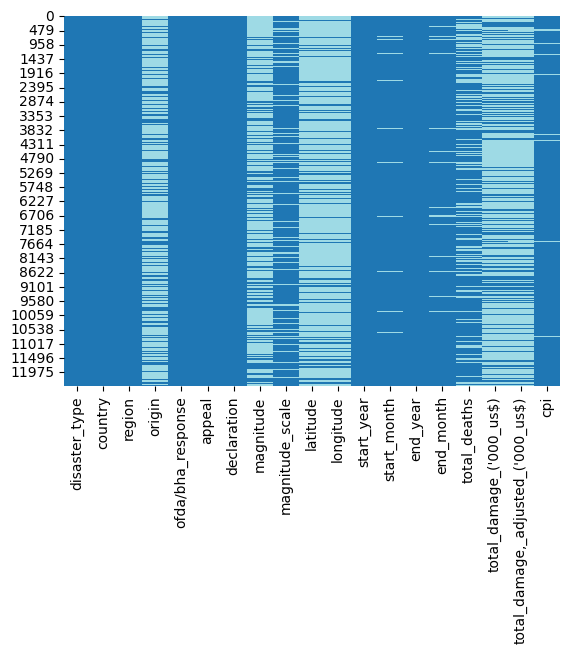

In [7]:
seaborn.heatmap(data_train.isnull(),cbar=False,cmap='tab20')
plt.show()

In [8]:
data_train.isnull().sum()

disaster_type                            0
country                                  0
region                                   0
origin                                9155
ofda/bha_response                        0
appeal                                   0
declaration                              0
magnitude                             8712
magnitude_scale                       1461
latitude                             10432
longitude                            10432
start_year                               0
start_month                            264
end_year                                 0
end_month                              472
total_deaths                          3486
total_damage_('000_us$)               8441
total_damage,_adjusted_('000_us$)     8494
cpi                                    282
dtype: int64

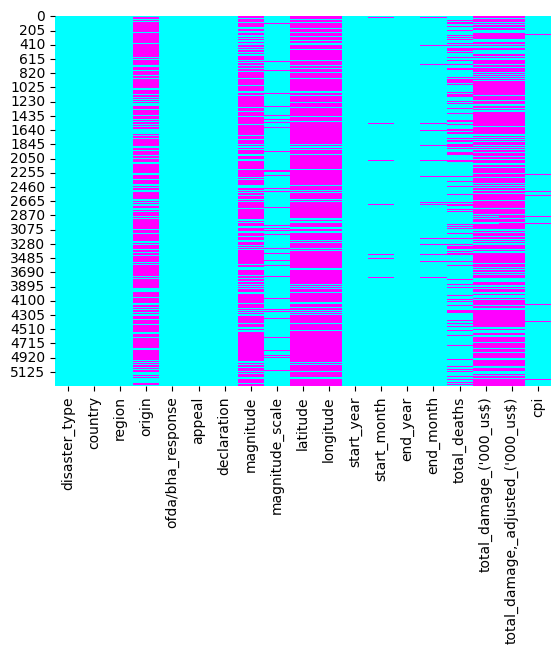

In [9]:
seaborn.heatmap(data_test.isnull(),cbar=False,cmap='cool')
plt.show()

In [10]:
data_test.isnull().sum()

disaster_type                           0
country                                 0
region                                  0
origin                               3884
ofda/bha_response                       0
appeal                                  0
declaration                             0
magnitude                            3756
magnitude_scale                       642
latitude                             4491
longitude                            4491
start_year                              0
start_month                           108
end_year                                0
end_month                             193
total_deaths                         1493
total_damage_('000_us$)              3600
total_damage,_adjusted_('000_us$)    3625
cpi                                   126
dtype: int64

In [11]:
data_train['disaster_type'].value_counts()

disaster_type
Flood                  4328
Storm                  3537
Earthquake             1156
Epidemic               1135
Landslide               643
Drought                 562
Extreme temperature     511
Wildfire                360
Volcanic activity       197
Name: count, dtype: int64

In [12]:
data_test['disaster_type'].value_counts()

disaster_type
Flood                  1855
Storm                  1516
Earthquake              495
Epidemic                487
Landslide               275
Drought                 241
Extreme temperature     219
Wildfire                154
Volcanic activity        85
Name: count, dtype: int64

In [13]:
data_train['disaster_type'].value_counts(normalize=True) * 100

disaster_type
Flood                  34.821788
Storm                  28.457639
Earthquake              9.300829
Epidemic                9.131869
Landslide               5.173385
Drought                 4.521683
Extreme temperature     4.111352
Wildfire                2.896452
Volcanic activity       1.585003
Name: proportion, dtype: float64

In [14]:
data_test['disaster_type'].value_counts(normalize=True) * 100

disaster_type
Flood                  34.822602
Storm                  28.458795
Earthquake              9.292285
Epidemic                9.142106
Landslide               5.162380
Drought                 4.524122
Extreme temperature     4.111132
Wildfire                2.890933
Volcanic activity       1.595645
Name: proportion, dtype: float64

In [15]:
# handling missing values
from sklearn.impute import SimpleImputer

In [16]:
# separate it first
X_train = data_train.drop("disaster_type", axis=1)
y_train = data_train["disaster_type"]

X_test = data_test.drop("disaster_type", axis=1)
y_test = data_test["disaster_type"]

In [17]:

categorical_features_train = data_train.select_dtypes(include=['object', 'category']).columns
categorical_features_train

Index(['disaster_type', 'country', 'region', 'origin', 'ofda/bha_response',
       'appeal', 'declaration', 'magnitude_scale'],
      dtype='object')

In [18]:
categorical_features_test = data_test.select_dtypes(include=['object', 'category']).columns
categorical_features_test

Index(['disaster_type', 'country', 'region', 'origin', 'ofda/bha_response',
       'appeal', 'declaration', 'magnitude_scale'],
      dtype='object')

In [19]:
categorical_features_data_train = data_train[categorical_features_train]
categorical_features_data_train

,disaster_type,country,region,origin,ofda/bha_response,appeal,declaration,magnitude_scale
0,Flood,United States of America,Americas,NaN,No,No,No,Km2
1,Drought,Ethiopia,Africa,NaN,Yes,No,No,Km2
2,Storm,China,Asia,NaN,No,No,No,Kph
3,Wildfire,Viet Nam,Asia,NaN,Yes,No,No,Km2
4,Earthquake,El Salvador,Americas,NaN,Yes,No,No,Moment Magnitude
...,...,...,...,...,...,...,...,...
12424,Earthquake,Libya,Africa,NaN,No,No,No,Moment Magnitude
12425,Flood,South Africa,Africa,Heavy rains,No,No,No,Km2
12426,Extreme temperature,India,Asia,NaN,No,No,No,°C
12427,Storm,Oman,Asia,NaN,No,No,No,Kph


In [20]:
categorical_features_data_test = data_test[categorical_features_test]
categorical_features_data_test

,disaster_type,country,region,origin,ofda/bha_response,appeal,declaration,magnitude_scale
0,Flood,Malaysia,Asia,Continuous rains,No,No,No,Km2
1,Flood,Peru,Americas,NaN,No,No,Yes,Km2
2,Flood,Guinea,Africa,Heavy rains,No,No,No,Km2
3,Wildfire,Nepal,Asia,Combination of well above normal temperature a...,No,No,No,Km2
4,Storm,India,Asia,NaN,No,No,No,Kph
...,...,...,...,...,...,...,...,...
5322,Earthquake,Türkiye,Asia,NaN,No,No,No,Moment Magnitude
5323,Flood,Indonesia,Asia,Heavy rains,No,No,No,Km2
5324,Drought,Côte d’Ivoire,Africa,NaN,No,No,No,Km2
5325,Flood,Iran (Islamic Republic of),Asia,Extreme rainfall,No,No,No,Km2


In [21]:
data_train.isnull().mean()*100

disaster_type                         0.000000
country                               0.000000
region                                0.000000
origin                               73.658380
ofda/bha_response                     0.000000
appeal                                0.000000
declaration                           0.000000
magnitude                            70.094135
magnitude_scale                      11.754767
latitude                             83.932738
longitude                            83.932738
start_year                            0.000000
start_month                           2.124065
end_year                              0.000000
end_month                             3.797570
total_deaths                         28.047309
total_damage_('000_us$)              67.913750
total_damage,_adjusted_('000_us$)    68.340172
cpi                                   2.268887
dtype: float64

In [22]:
categorical_impute= SimpleImputer(strategy='most_frequent')
categorical_impute

SimpleImputer(strategy='most_frequent')

In [23]:
categorical_impute.fit(categorical_features_data_train)

SimpleImputer(strategy='most_frequent')

In [24]:
categorical_features_data_train = pd.DataFrame(
    data = categorical_impute.transform(categorical_features_data_train),
    columns = categorical_impute.get_feature_names_out(),
    index = categorical_features_data_train.index
)
categorical_features_data_train

,disaster_type,country,region,origin,ofda/bha_response,appeal,declaration,magnitude_scale
0,Flood,United States of America,Americas,Heavy rains,No,No,No,Km2
1,Drought,Ethiopia,Africa,Heavy rains,Yes,No,No,Km2
2,Storm,China,Asia,Heavy rains,No,No,No,Kph
3,Wildfire,Viet Nam,Asia,Heavy rains,Yes,No,No,Km2
4,Earthquake,El Salvador,Americas,Heavy rains,Yes,No,No,Moment Magnitude
...,...,...,...,...,...,...,...,...
12424,Earthquake,Libya,Africa,Heavy rains,No,No,No,Moment Magnitude
12425,Flood,South Africa,Africa,Heavy rains,No,No,No,Km2
12426,Extreme temperature,India,Asia,Heavy rains,No,No,No,°C
12427,Storm,Oman,Asia,Heavy rains,No,No,No,Kph


In [25]:
categorical_features_data_test = pd.DataFrame(
    data = categorical_impute.transform(categorical_features_data_test),
    columns = categorical_impute.get_feature_names_out(),
    index = categorical_features_data_test.index
)
categorical_features_data_test

,disaster_type,country,region,origin,ofda/bha_response,appeal,declaration,magnitude_scale
0,Flood,Malaysia,Asia,Continuous rains,No,No,No,Km2
1,Flood,Peru,Americas,Heavy rains,No,No,Yes,Km2
2,Flood,Guinea,Africa,Heavy rains,No,No,No,Km2
3,Wildfire,Nepal,Asia,Combination of well above normal temperature a...,No,No,No,Km2
4,Storm,India,Asia,Heavy rains,No,No,No,Kph
...,...,...,...,...,...,...,...,...
5322,Earthquake,Türkiye,Asia,Heavy rains,No,No,No,Moment Magnitude
5323,Flood,Indonesia,Asia,Heavy rains,No,No,No,Km2
5324,Drought,Côte d’Ivoire,Africa,Heavy rains,No,No,No,Km2
5325,Flood,Iran (Islamic Republic of),Asia,Extreme rainfall,No,No,No,Km2


In [26]:
categorical_features_data_train.isnull().sum()

disaster_type        0
country              0
region               0
origin               0
ofda/bha_response    0
appeal               0
declaration          0
magnitude_scale      0
dtype: int64

In [27]:

categorical_features_data_test.isnull().sum()

disaster_type        0
country              0
region               0
origin               0
ofda/bha_response    0
appeal               0
declaration          0
magnitude_scale      0
dtype: int64

In [28]:
numerical_features = [
    'magnitude',
    'latitude',
    'longitude',
    'start_year',
    'start_month',
]

In [29]:
numerical_features_data_train = data_train[numerical_features]
numerical_features_data_train

,magnitude,latitude,longitude,start_year,start_month
0,NaN,NaN,NaN,1977,9.0
1,NaN,NaN,NaN,2021,5.0
2,NaN,NaN,NaN,2014,8.0
3,55.0,NaN,NaN,2002,3.0
4,6.6,13.671,-88.938,2001,2.0
...,...,...,...,...,...
12424,5.4,32.600,21.000,1963,2.0
12425,NaN,NaN,NaN,2019,5.0
12426,NaN,NaN,NaN,1985,12.0
12427,NaN,NaN,NaN,2003,4.0


In [30]:

numerical_features_data_test = data_test[numerical_features]
numerical_features_data_test

,magnitude,latitude,longitude,start_year,start_month
0,NaN,NaN,NaN,2003,10.0
1,NaN,NaN,NaN,2015,4.0
2,NaN,NaN,NaN,2024,7.0
3,NaN,NaN,NaN,2016,2.0
4,110.0,NaN,NaN,2009,5.0
...,...,...,...,...,...
5322,6.0,41.7,43.8,1940,5.0
5323,NaN,NaN,NaN,2014,1.0
5324,NaN,NaN,NaN,1983,NaN
5325,NaN,NaN,NaN,2017,8.0


In [31]:
# add missing indicators
from sklearn.impute import MissingIndicator

indicator = MissingIndicator(features='missing-only')

missing_flags = indicator.fit_transform(numerical_features_data_train[['magnitude','latitude','longitude']])

In [32]:
from sklearn.impute import MissingIndicator

indicator = MissingIndicator(features='missing-only')

missing_flags = indicator.fit_transform(numerical_features_data_test[['magnitude','latitude','longitude']])

In [33]:
# impute values
from sklearn.impute import KNNImputer

In [34]:
imputer = KNNImputer(n_neighbors=5)

num_cols = ['magnitude','latitude','longitude','start_year','start_month']
numerical_features_data_train[num_cols] = imputer.fit_transform(numerical_features_data_train[num_cols])

/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/var/folders/b6/77jq3l_n51s4g5kpd815pg140000gn/T/ipykernel_2496/3726702947.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numerical_features_data_train[num_cols] = imputer.fit_transform(numerical_features_data_train[num_cols])


In [35]:
imputer = KNNImputer(n_neighbors=5)

num_cols = ['magnitude','latitude','longitude','start_year','start_month']
numerical_features_data_test[num_cols] = imputer.fit_transform(numerical_features_data_test[num_cols])

/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yazu/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/var/folders/b6/77jq3l_n51s4g5kpd815pg140000gn/T/ipykernel_2496/2127200959.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numerical_features_data_test[num_cols] = imputer.fit_transform(numerical_features_data_test[num_cols])


In [36]:
numerical_features_data_train.isna().sum(axis='index')

magnitude      0
latitude       0
longitude      0
start_year     0
start_month    0
dtype: int64

In [37]:
categorical_features_data_train.isna().sum(axis='index')

disaster_type        0
country              0
region               0
origin               0
ofda/bha_response    0
appeal               0
declaration          0
magnitude_scale      0
dtype: int64

In [38]:
train_processed = (
    categorical_features_data_train
    .join(numerical_features_data_train)
)

train_processed['disaster_type'] = y_train

In [39]:
train_processed.head()

,disaster_type,country,region,origin,ofda/bha_response,appeal,declaration,magnitude_scale,magnitude,latitude,longitude,start_year,start_month
0,Flood,United States of America,Americas,Heavy rains,No,No,No,Km2,146.860,10.74520,96.1320,1977.0,9.0
1,Drought,Ethiopia,Africa,Heavy rains,Yes,No,No,Km2,107.900,21.82460,73.3240,2021.0,5.0
2,Storm,China,Asia,Heavy rains,No,No,No,Kph,4627.802,8.54302,19.8346,2014.0,8.0
3,Wildfire,Viet Nam,Asia,Heavy rains,Yes,No,No,Km2,55.000,11.00280,-30.5654,2002.0,3.0
4,Earthquake,El Salvador,Americas,Heavy rains,Yes,No,No,Moment Magnitude,6.600,13.67100,-88.9380,2001.0,2.0
